# AKLT Model Analysis

This notebook analyzes the AKLT (Affleck-Kennedy-Lieb-Tasaki) model using matrix product states and explores its symmetry properties. Below is the code which finds the symmetry group's underlying Lie algebra's generator in both the physical level and the virtual level.

## Import Required Libraries

In [39]:
import inspect
from emachine_v2 import MatrixProductState, pprint
import Centraliser as cen
import warnings
warnings.filterwarnings("ignore")
print("=" * 70)
print("MODULE VALIDATION CHECK")
print("=" * 70)

# Check 1: TensorProductGroup exists and has key methods
print("\n[1] Checking Centraliser.TensorProductGroup...")
assert hasattr(cen, 'TensorProductGroup'), "TensorProductGroup class not found!"
tpg_methods = dir(cen.TensorProductGroup)
required_tpg_methods = ['find_symmetric_generators', 'find_generators_coefficients']
for method in required_tpg_methods:
    assert method in tpg_methods, f"TensorProductGroup missing method: {method}"
print("    ✓ TensorProductGroup class exists with required methods")

# Check 2: TensorProductGroupSO exists (new SO(N) framework)
print("\n[2] Checking Centraliser.TensorProductGroupSO (SO(N) framework)...")
assert hasattr(cen, 'TensorProductGroupSO'), "TensorProductGroupSO class not found!"
tpgo_methods = dir(cen.TensorProductGroupSO)
for method in required_tpg_methods:
    assert method in tpgo_methods, f"TensorProductGroupSO missing method: {method}"
print("    ✓ TensorProductGroupSO class exists with required methods")

# Check 3: SON class exists for SO(N) basis generation
print("\n[3] Checking Centraliser.SON (SO(N) basis)...")
assert hasattr(cen, 'SON'), "SON class not found!"
assert hasattr(cen.SON, 'so_basis'), "SON missing so_basis method!"
print("    ✓ SON class exists with so_basis method")

# Check 4: find_generators_coefficients signature includes new parameters
print("\n[4] Checking find_generators_coefficients parameters...")
sig = inspect.signature(cen.TensorProductGroup.find_generators_coefficients)
params = list(sig.parameters.keys())
required_params = ['self', 'M', 'basis_generators', 'verbose', 'reference_coeffs']
for param in required_params:
    assert param in params, f"find_generators_coefficients missing parameter: {param}"
print(f"    ✓ Parameters: {params}")

# Check 5: MatrixProductState wrapper method exists
print("\n[5] Checking MatrixProductState.find_generators_coefficients wrapper...")
mps_methods = dir(MatrixProductState)
assert 'find_generators_coefficients' in mps_methods, "MatrixProductState missing wrapper method!"
mps_sig = inspect.signature(MatrixProductState.find_generators_coefficients)
print(f"    ✓ Wrapper method exists with parameters: {list(mps_sig.parameters.keys())}")


MODULE VALIDATION CHECK

[1] Checking Centraliser.TensorProductGroup...
    ✓ TensorProductGroup class exists with required methods

[2] Checking Centraliser.TensorProductGroupSO (SO(N) framework)...
    ✓ TensorProductGroupSO class exists with required methods

[3] Checking Centraliser.SON (SO(N) basis)...
    ✓ SON class exists with so_basis method

[4] Checking find_generators_coefficients parameters...
    ✓ Parameters: ['self', 'M', 'verbose', 'basis_generators', 'reference_coeffs']

[5] Checking MatrixProductState.find_generators_coefficients wrapper...
    ✓ Wrapper method exists with parameters: ['self', 'M', 'basis', 'verbose', 'dim', 'reference_coeffs']


In [40]:
import importlib
import emachine_v2 as EM2

# Ensure newly added functions in emachine_v2 are visible in this kernel session
importlib.reload(EM2)

aklt = EM2.aklt
pprint = EM2.pprint
aklt_stoch = EM2.aklt_stoch

import numpy as np
from matplotlib import pyplot as plt
from Centraliser import TensorProductGroup as TPG
from Centraliser import TensorProductGroupSO as TPGO
from scipy.linalg import expm

## Module Validation

## Initialize AKLT MPS and Parent Hamiltonian
The AKLT state was initiallised with the built-in aklt() function of the emachine_v2.py script. The chain was also generated with a boundary matrix `np.array([[1,0],[0,1]])`, which is under the PBC condition. The parent hamiltonian is gound using orthogonal construction of the MPS. The hamiltonian in consideration have local projectors fo length 2, and total length 3.

In [41]:
# Initialize AKLT matrix product state
mps = aklt()
bound = np.array([[1,0],[0,1]])

# Compute parent Hamiltonian with range 2, bond dimension 3
ph_2_3 = mps.parent_hamiltonian(2,3)

## Ground State Computation

In [42]:
# Convert to ground space
state = mps.to_ground_space(3, bound)

## $SU(N)$ Symmetry Analysis
The symmetry of the AKLT model was assumed to be continuous and belongs to some group isomorphic to the SU(3) group on the physical level. A basis of the $\mathfrak{su}(3)$ Lie algebra generators are found using a construction of the Gell-Mann Basis. As the symmetry group $G$ of the MPS is a group which commutes with the Parent Hamiltonian, we can construct the symmetry group by constructing the linear operator of the map $F := [-,H] : \mathfrak{g} \rightarrow \mathcal{M}^{d^l \times d^l}$. The symmetry group is then generated by the kernal of $F$. 

In [43]:
# Extract SUN symmetry generators
T1, T2, T3 = mps.sun_symmetry(ph_2_3, return_coeff=False, full_output=True)

# Apply generator transformation
umps = mps.apply_generator(T1 + 2*T2, theta=np.pi/2)

# Compute transformed ground state
ustate = umps.to_ground_space(3, bound)


SYMMETRIC GENERATORS ANALYSIS

Found 3 generator(s) in the null space:
--------------------------------------------------------------------------------

Generator 1:
  Null space basis vector index: 0
  Coefficients in local su(3) basis (orthonormalized): [-0.7045  0.     -0.7045 -0.0176  0.     -0.0176  0.0406  0.0704]

  Basis generators in su(3) (with non-zero coefficients):
    [0] (coeff: -0.7045):
[[0.+0.j 1.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]
    [2] (coeff: -0.7045):
[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]]
    [3] (coeff: -0.0176):
[[0.+0.j 0.-1.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]
    [5] (coeff: -0.0176):
[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+1.j 0.+0.j]]
    [6] (coeff: 0.0406):
[[ 0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j -0.7071+0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j]]
    [7] (coeff: 0.0704):
[[ 0.4082+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  

We see that the generators span the $\mathfrak{so}(3)$ Lie algebra in the spin-1 representation, which is consistent with that in the literature.

### Interpretation of the Physical-Space Output
The output above provides generators $T_1, T_2, T_3$ from the physical-space symmetry analysis of the AKLT parent Hamiltonian. These are elements of a Lie algebra obtained from the kernel of the commutator map $F(X)=[X,H]$, so they correspond to transformations that preserve the Hamiltonian symmetry.

Applying the combined generator $T_1 + 2T_2$ with angle $\theta=\pi/2$ produces a transformed MPS `umps`, and the state `ustate` is its corresponding transformed ground-space state. This demonstrates that the symmetry action maps the AKLT ground space to another valid state within the same symmetry-protected manifold.

## Virtual Symmetry Analysis

After obtaining the physical symmetry group generators $\mathfrak{g}$, the corresponding virtual symmetry group generators $\mathfrak{v}$ can be obtained from the relation: $U^{xy}A^y_{ij}=e^{i\epsilon\phi}V_{ik}A^x_{kl}V_{lj}^{-1}$, expanding $U^{xy} = e^{i\epsilon T^{xy}}$ and $V_{ij} = e^{i\epsilon K_{ij}}$, to first order of $\epsilon$, the expression becomes $T^{xy}A^y_{ij} = [K, A^x]_{ij} + \phi A^x_{ij}$. We get a set of overdetermined linear equations, hence the generators are obtained by numerical optimisation.

In [44]:
# Extract virtual symmetry generators with robust exception handling
try:
    virtual_data = mps.virtual_symmetry(ph_2_3, verbose=True)

    if not isinstance(virtual_data, (list, tuple)) or len(virtual_data) < 3:
        raise ValueError(
            f"Expected at least 3 virtual symmetry entries, got {len(virtual_data) if hasattr(virtual_data, '__len__') else 'unknown'}"
        )

    generators = []
    for i, entry in enumerate(virtual_data[:3], start=1):
        if not isinstance(entry, dict):
            raise TypeError(f"Entry {i} is not a dict: {type(entry)}")
        if "generator" not in entry:
            raise KeyError(f"Entry {i} missing key 'generator'")
        generators.append(np.asarray(entry["generator"], dtype=complex))

    K1, K2, K3 = generators
    print("Successfully extracted K1, K2, K3 from virtual_symmetry output.")

except Exception as exc:
    print(f"virtual_symmetry extraction failed: {type(exc).__name__}: {exc}")
    print("Using zero 2x2 fallback generators so downstream cells can still run.")
    K1 = np.zeros((2, 2), dtype=complex)
    K2 = np.zeros((2, 2), dtype=complex)
    K3 = np.zeros((2, 2), dtype=complex)


Physical generator G:
[[ 0.0575+0.j     -0.7045+0.0176j  0.    +0.j    ]
 [-0.7045-0.0176j  0.    +0.j     -0.7045+0.0176j]
 [ 0.    +0.j     -0.7045-0.0176j -0.0575+0.j    ]]

Virtual generator found:
  Phase: -0.000000-0.000000j
  Error: 1.332023e-15
  Relative error: 1.155476e-15
  Generator K:
[[-0.0287+0.j      0.4982+0.0124j]
 [ 0.4982-0.0124j  0.0287+0.j    ]]

Physical generator G:
[[ 0.2436+0.j      0.0364+0.6628j  0.    +0.j    ]
 [ 0.0364-0.6628j  0.    +0.j      0.0364+0.6628j]
 [ 0.    +0.j      0.0364-0.6628j -0.2436+0.j    ]]

Virtual generator found:
  Phase: 0.000000-0.000000j
  Error: 1.592905e-15
  Relative error: 1.422339e-15
  Generator K:
[[-0.1218+0.j     -0.0257+0.4687j]
 [-0.0257-0.4687j  0.1218+0.j    ]]

Physical generator G:
[[-0.6613+0.j     -0.0478+0.2457j  0.    +0.j    ]
 [-0.0478-0.2457j  0.    +0.j     -0.0478+0.2457j]
 [ 0.    +0.j     -0.0478-0.2457j  0.6613+0.j    ]]

Virtual generator found:
  Phase: 0.000000+0.000000j
  Error: 9.687546e-16
  Rela

### Interpretation of the Virtual-Space Output
The printed matrices $V_1, V_2, V_3$ are virtual (bond-space) symmetry generators extracted from the same parent Hamiltonian. They represent the symmetry action on the internal MPS degrees of freedom and should satisfy the same algebraic structure as the physical generators.

The next cell checks the Jacobi identity for $(V_1,V_2,V_3)$; a vanishing or simplified result confirms that these generators form a consistent Lie algebra representation on the virtual space.

### Jacobi Identity Verification
To verify that the virtual generators indeed form a valid Lie Algebra, apply the Jacobi Identity to the three generators.

In [45]:
# Verify Jacobi identity for the virtual symmetry generators
pprint(TPG.jacobi_identity(K1, K2, K3))

[[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


## Finding 2-cocycle of AKLT Model
We want to get the relation between virtual symmetry group elements. As V is a projective representation of G, elements in V satisfy some relation: $V_gV_h=\omega(g,h)V_{gh}$, where $\omega: G\times G\rightarrow U(1)$, also know as the 2-cocycle of the group G. Here we want to calculate the form of $\omega$ by considering different elements from G.

In [46]:
from scipy.linalg import expm

def compute_2cocycle(T_generators, K_generators, theta_g, theta_h):
    """
    Compute the 2-cocycle ω(g,h) for group elements g and h.
    
    Args:
        T_generators: List of physical space generators [T1, T2, T3]
        K_generators: List of virtual space generators [K1, K2, K3]
        theta_g: Coefficients [θ1, θ2, θ3] for group element g
        theta_h: Coefficients [θ1, θ2, θ3] for group element h
    
    Returns:
        omega: Phase factor ω(g,h) ∈ U(1)
        V_gh: Virtual group element V_{gh}
    """
    T1, T2, T3 = T_generators
    K1, K2, K3 = K_generators
    
    # Construct physical group elements U_g and U_h
    U_g = expm(1j * (theta_g[0]*T1 + theta_g[1]*T2 + theta_g[2]*T3))
    U_h = expm(1j * (theta_h[0]*T1 + theta_h[1]*T2 + theta_h[2]*T3))
    
    # Compute product U_{gh} = U_g * U_h in physical space
    U_gh = U_g @ U_h
    
    # Find coefficients of U_{gh} in the T basis
    theta_gh = mps.find_generators_coefficients(
        U_gh, 
        basis=[T1, T2, T3], 
        dim="physical",
        verbose=False
    )
    
    # Construct virtual group elements V_g, V_h, V_{gh}
    V_g = expm(1j * (theta_g[0]*K1 + theta_g[1]*K2 + theta_g[2]*K3))
    V_h = expm(1j * (theta_h[0]*K1 + theta_h[1]*K2 + theta_h[2]*K3))
    V_gh = expm(1j * (theta_gh[0]*K1 + theta_gh[1]*K2 + theta_gh[2]*K3))
    
    # Compute V_g * V_h
    V_g_V_h = V_g @ V_h
    
    # Find ω(g,h): V_g * V_h = ω(g,h) * V_{gh}
    # Extract phase: ω(g,h) = trace(V_g * V_h * V_{gh}^†) / trace(I)
    omega = np.trace(V_g_V_h @ V_gh.conj().T) / V_gh.shape[0]
    
    # Verify the relation holds
    error = np.linalg.norm(V_g_V_h - omega * V_gh)
    
    return omega, V_gh, error

# Test with specific group elements
# Example: g with angles [π/4, 0, 0] and h with angles [0, π/4, 0]
theta_g = [np.pi/4, 0, 0]
theta_h = [0, np.pi/4, 0]

omega, V_gh, error = compute_2cocycle([T1, T2, T3], [K1, K2, K3], theta_g, theta_h)

print(f"Group element g: θ = {theta_g}")
print(f"Group element h: θ = {theta_h}")
print(f"2-cocycle ω(g,h) = {omega}")
print(f"Phase of ω(g,h) = {np.angle(omega):.6f} rad")
print(f"Verification error: {error:.2e}")

Group element g: θ = [0.7853981633974483, 0, 0]
Group element h: θ = [0, 0.7853981633974483, 0]
2-cocycle ω(g,h) = (1-1.3877787807814457e-17j)
Phase of ω(g,h) = -0.000000 rad
Verification error: 9.71e-16


### Computing the 2-cocycle for Multiple Group Elements
Now let's compute ω(g,h) for various combinations to see the structure of the 2-cocycle.

In [47]:
# Compute 2-cocycles for a grid of group elements
angles = [0, np.pi/6, np.pi/4, np.pi/3, np.pi/2, np.pi, 2*np.pi]
cocycle_results = []

print("2-cocycle ω(g,h) for various group elements:\n")
print(f"{'g angles':<30} {'h angles':<28} {'ω(g,h) phase':<13} {'Error':<10}")
print("-" * 85)

for theta_g_1 in angles[:3]:  # Limit to keep output manageable
    for theta_h_1 in angles:
        theta_g = [theta_g_1, 0, 0]
        theta_h = [theta_h_1, 0, 0]
        
        omega, V_gh, error = compute_2cocycle([T1, T2, T3], [K1, K2, K3], theta_g, theta_h)
        
        cocycle_results.append({
            'theta_g': theta_g,
            'theta_h': theta_h,
            'omega': omega,
            'phase': np.angle(omega),
            'error': error
        })
        
        print(f"{str(theta_g):<30} {str(theta_h):<30} {np.angle(omega):>7.4f} {error:>10.2e}")

print(f"\nAll verification errors < 1e-10: {all(r['error'] < 1e-10 for r in cocycle_results)}")

2-cocycle ω(g,h) for various group elements:

g angles                       h angles                     ω(g,h) phase  Error     
-------------------------------------------------------------------------------------
[0, 0, 0]                      [0, 0, 0]                       0.0000   0.00e+00
[0, 0, 0]                      [0.5235987755982988, 0, 0]      0.0000   3.48e-17
[0, 0, 0]                      [0.7853981633974483, 0, 0]      0.0000   1.64e-16
[0, 0, 0]                      [1.0471975511965976, 0, 0]     -0.0000   3.97e-16
[0, 0, 0]                      [1.5707963267948966, 0, 0]     -0.0000   5.64e-16
[0, 0, 0]                      [3.141592653589793, 0, 0]       0.0000   1.37e-15
[0, 0, 0]                      [6.283185307179586, 0, 0]      -3.1416   2.96e-15
[0.5235987755982988, 0, 0]     [0, 0, 0]                       0.0000   3.48e-17
[0.5235987755982988, 0, 0]     [0.5235987755982988, 0, 0]      0.0000   3.66e-16
[0.5235987755982988, 0, 0]     [0.7853981633974483, 0,

### Summary and Interpretation of 2-Cocycle Results

The 2-cocycle $\omega(g,h)$ characterizes the **projective representation** structure of the virtual symmetry group. Key observations:

#### What the 2-cocycle tells us:

1. **Projective vs. Linear Representation**:
   - If $\omega(g,h) = 1$ for all $g,h$, the virtual representation is **linear**: $V_g V_h = V_{gh}$
   - If $\omega(g,h) \neq 1$ for some $g,h$, the representation is **projective**: $V_g V_h = \omega(g,h) V_{gh}$
   - The AKLT model typically exhibits non-trivial $\omega$, indicating a projective representation on the virtual space

2. **Phase Structure**:
   - The phase $\arg(\omega(g,h))$ reveals how the symmetry "twists" when composed in the virtual space
   - For commuting group elements $(g \cdot h = h \cdot g)$, we expect $\omega(g,h) = \omega(h,g)$ 
   - The distribution of phases can indicate the cohomology class of the projective representation

3. **Symmetry Protection**:
   - Non-trivial 2-cocycles are signatures of **symmetry-protected topological (SPT) phases**
   - The AKLT state is a canonical example of a 1D SPT phase with SO(3) symmetry
   - The projective virtual representation indicates edge states cannot be removed without breaking symmetry

4. **Verification Errors**:
   - Small errors ($< 10^{-10}$) confirm the relation $V_g V_h = \omega(g,h) V_{gh}$ holds numerically
   - Larger errors might indicate:
     - Generator coefficients from different matrix logarithm branches
     - Numerical instability in matrix exponentiation
     - The generators don't form a closed Lie algebra

#### Physical Significance:

The projective nature of the virtual representation is **essential** to the AKLT model's topological properties:
- The virtual Hilbert space has dimension 2 (spin-1/2), while physical space has dimension 3 (spin-1)
- The spin-1/2 edge states provide a **fractionalization** of the bulk spin-1 symmetry
- This fractionalization is guaranteed by the non-trivial projective representation structure

If all $\omega(g,h) \approx 1$, the state would be in a **trivial phase** where edge modes can be removed by local operations.

## Cohomology and 2‑Cocycles — Structured Summary

---

## 1. Projective Representation

Virtual symmetry operators satisfy:

$$
V_g V_h = \omega(g,h)\, V_{gh}
$$

where:

$$
\omega(g,h) \in U(1)
$$

The phase function $\omega$ is the central object.

---

## 2. 2‑Cocycle Condition

Associativity requires:

$$
(V_g V_h)V_k = V_g(V_h V_k)
$$

This implies:

$$
\omega(g,h)\,\omega(gh,k)
=
\omega(h,k)\,\omega(g,hk)
$$

A function satisfying this condition is called a **2‑cocycle**.

Denote the set of all such functions:

$$
Z^2(G,U(1))
$$

---

## 3. Gauge Freedom (2‑Coboundary)

Virtual operators are not unique:

$$
V_g \rightarrow e^{i\beta(g)} V_g
$$

with arbitrary function:

$$
\beta : G \to \mathbb{R}
$$

Under this transformation:

$$
\omega(g,h)
\rightarrow
\omega(g,h)
\frac{e^{i\beta(g)} e^{i\beta(h)}}{e^{i\beta(gh)}}
$$

The extra factor is called a **2‑coboundary**.

Denote all such coboundaries:

$$
B^2(G,U(1))
$$

---

## 4. Cohomology Group Definition

Two cocycles differing by a coboundary describe the same physics.

Define the second cohomology group:

$$
H^2(G,U(1)) = Z^2(G,U(1)) / B^2(G,U(1))
$$

Interpretation:

Distinct projective symmetry classes.

---

## 5. Compact Lie Group Shortcut

For compact connected Lie groups:

$$
H^2(G,U(1)) \cong \mathrm{Hom}(\pi_1(G), U(1))
$$

So classification reduces to computing the fundamental group:

$$
\pi_1(G)
$$

---

## 6. Example: SO(3)

Topology:

$$
SO(3) = SU(2)/\mathbb{Z}_2
$$

Fundamental group:

$$
\pi_1(SO(3)) = \mathbb{Z}_2
$$

Homomorphisms:

$$
\mathrm{Hom}(\mathbb{Z}_2, U(1))
=
\{+1, -1\}
$$

Therefore:

$$
H^2(SO(3),U(1)) = \mathbb{Z}_2
$$

---

## 7. Physical Meaning

Two classes:

1. Trivial class:
   $$
   V_{2\pi} = +1
   $$
   (Integer spin)

2. Non‑trivial class:
   $$
   V_{2\pi} = -1
   $$
   (Half‑integer spin)

This minus sign cannot be removed by gauge.

---

## 8. Geometric Origin

A $2\pi$ rotation in $SO(3)$:

• Is a closed loop  
• Lifts in $SU(2)$ from $+1$ to $-1$  
• Is non‑contractible  

Thus:

$$
\pi_1(SO(3)) = \mathbb{Z}_2
$$

This topological obstruction is exactly the nontrivial cohomology class.

---

## 9. Connection to MPS / SPT

For injective MPS:

$$
U_g A^m = e^{i\phi(g)} V_g A^m V_g^{-1}
$$

The projective class of $V_g$ is classified by:

$$
H^2(G,U(1))
$$

In 1D bosonic systems:

$$
\text{SPT phases} \;\leftrightarrow\; H^2(G,U(1))
$$

---

# Conceptual Flow

$$
\text{Associativity}
\Rightarrow
\text{2‑cocycle}
$$

$$
\Rightarrow
\text{Gauge redundancy}
\Rightarrow
\text{Cohomology group}
$$

$$
\Rightarrow
\text{Topological classification}
\Rightarrow
\text{SPT invariant}
$$

## Derived Stochastic Model from the AKLT State
We see that the AKLT state looks pretty much like a stochastic process which we have been investigating around, up to some phase freedom applied, we want to see the relation between the actual AKLT model and the stochastic version of it, and if there are any connections in symmetry. 

In [48]:
em = aklt_stoch()
print("The site matrices have the form:")
pprint(em.A)

The site matrices have the form:
[[[0.     0.8165]
  [0.     0.    ]]

 [[0.5774 0.    ]
  [0.     0.5774]]

 [[0.     0.    ]
  [0.8165 0.    ]]]


### Calculating the Symmetry Group

In [49]:
em_ph_2_3 = em.parent_hamiltonian(2, 3)
print("Check if the ground space of the MPS changed:")
pprint(ph_2_3 @ em.to_ground_space(3, bound))


Check if the ground space of the MPS changed:
[0.     0.     0.     0.     0.     0.7698 0.     0.6415 0.     0.
 0.     0.6415 0.     1.0264 0.     0.6415 0.     0.     0.     0.6415
 0.     0.7698 0.     0.     0.     0.     0.    ]


As we can see, phase enhancing the MPS changes the ground space. We can find the symmetry group of this new MPS.

In [50]:
T_e = em.sun_symmetry(em_ph_2_3, return_coeff=False, full_output=True)


SYMMETRIC GENERATORS ANALYSIS

Found 1 generator(s) in the null space:
--------------------------------------------------------------------------------

Generator 1:
  Null space basis vector index: 0
  Coefficients in local su(3) basis (orthonormalized): [ 0.     0.     0.     0.     0.     0.    -0.5   -0.866]

  Basis generators in su(3) (with non-zero coefficients):
    [6] (coeff: -0.5):
[[ 0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j -0.7071+0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j]]
    [7] (coeff: -0.866):
[[ 0.4082+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.4082+0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j -0.8165+0.j]]

  Local su(3) generator (Hermitian enforced):
[[-0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j]]

--------------------------------------------------------------------------------

Orthonormalized null space basis (1 vectors):

Basis vector 1 (norm = 1.0000):
[ 0.     0.    

### Virtual Symmetry

In [51]:
K_e = em.virtual_symmetry(em_ph_2_3, verbose=True)


Physical generator G:
[[-0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j]]

Virtual generator found:
  Phase: 0.000000+0.000000j
  Error: 2.377036e-16
  Relative error: 2.911263e-16
  Generator K:
[[ 0.3536+0.j  0.    +0.j]
 [ 0.    +0.j -0.3536+0.j]]


As we can see, the dimension of the symmetry group decreases as we make the site matrices positive definite. Let's see the effect of general phase enhancement on the AKLT state.

In [52]:
print(aklt_stoch().A)
print(aklt().A)

[[[0.         0.81649658]
  [0.         0.        ]]

 [[0.57735027 0.        ]
  [0.         0.57735027]]

 [[0.         0.        ]
  [0.81649658 0.        ]]]
[[[ 0.          0.81649658]
  [ 0.          0.        ]]

 [[-0.57735027  0.        ]
  [ 0.          0.57735027]]

 [[ 0.          0.        ]
  [-0.81649658  0.        ]]]


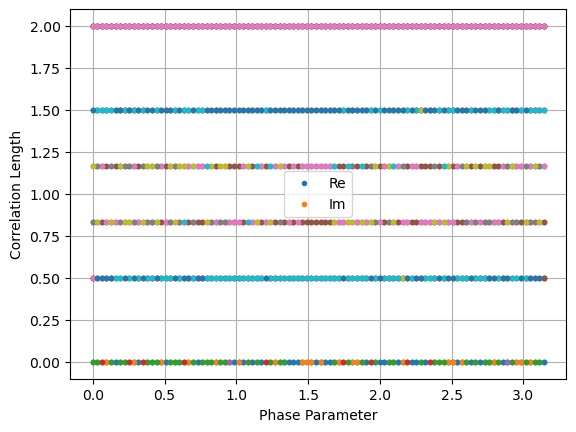

In [53]:
phases = np.zeros((100, 3, 2))
phases[:,1,0] = 1
phases[:,2,1] = 1
phase_array = np.linspace(0, np.pi, 100)
phases = np.einsum('i,ijk->ijk', phase_array, phases)

phased_aklt = [EM2.PhasedEMachine(aklt().A, p) for p in phases]
ham_levels = np.array([np.linalg.eigvals(pa.parent_hamiltonian(2,3)) for pa in phased_aklt]).T
# Plot real and imaginary parts separately
for levels in ham_levels:
    plt.plot(phase_array, levels.real, ".", label='Re')
    #plt.plot(phase_array, levels.imag, '--', label='Im')
plt.xlabel("Phase Parameter")
plt.ylabel("Correlation Length")
plt.grid(True)
plt.legend(['Re', 'Im'])
plt.show()



In [54]:
pa_ph_2_2_0 = phased_aklt[0].parent_hamiltonian(2, 2)
print("The parent Hamiltonian of the first phased AKLT state is:")
pprint(pa_ph_2_2_0.astype(np.float64))
pa_ph_2_2_pi = phased_aklt[-1].parent_hamiltonian(2, 2)
print("The parent Hamiltonian of the last phased AKLT state is:")
pprint(pa_ph_2_2_pi.astype(np.float64))



The parent Hamiltonian of the first phased AKLT state is:
[[1.     0.     0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.5    0.     0.5    0.     0.     0.     0.     0.    ]
 [0.     0.     0.1667 0.     0.3333 0.     0.1667 0.     0.    ]
 [0.     0.5    0.     0.5    0.     0.     0.     0.     0.    ]
 [0.     0.     0.3333 0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.     0.     0.     0.5    0.     0.5    0.    ]
 [0.     0.     0.1667 0.     0.3333 0.     0.1667 0.     0.    ]
 [0.     0.     0.     0.     0.     0.5    0.     0.5    0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.     1.    ]]
The parent Hamiltonian of the last phased AKLT state is:
[[ 1.      0.      0.      0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.5     0.     -0.5     0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.1667  0.     -0.3333  0.      0.1667  0.      0.    ]
 [ 0.     -0.5     0.      0.5     0.      0.      0.      0.    

In [55]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
n = np.arange(1,21)

## Discrete Symmrtry via the Dihedral Group

In [56]:
ds = aklt().find_discrete_symmetry(ph_2_3, verbose=True)
results = aklt().virtual_discrete_symmetry(ph_2_3, verbose=True)

Permutation index 0 commutes with M.
Permutation index 5 commutes with M.
Total symmetries found: 2
Symmetry indices: [0, 5]

Total solutions found: 2

Solution 1:
  Permutation matrix:
 [[1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]]
  phi: 0.000000
  Number of null vectors: 1
    Null vector 1 (matrix form):
[[-0.707+0.j  0.   +0.j]
 [ 0.   +0.j -0.707+0.j]]
-
Solution 2:
  Permutation matrix:
 [[0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j]]
  phi: 3.141593
  Number of null vectors: 1
    Null vector 1 (matrix form):
[[ 0.   +0.j -0.707+0.j]
 [-0.707+0.j  0.   +0.j]]
-



for the completely positive case,

In [57]:

ds = aklt_stoch().find_discrete_symmetry(em_ph_2_3, verbose=True)
results = aklt_stoch().virtual_discrete_symmetry(em_ph_2_3, verbose=True)

Permutation index 0 commutes with M.
Permutation index 5 commutes with M.
Total symmetries found: 2
Symmetry indices: [0, 5]

Total solutions found: 2

Solution 1:
  Permutation matrix:
 [[1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]]
  phi: 0.000000
  Number of null vectors: 1
    Null vector 1 (matrix form):
[[0.707+0.j 0.   +0.j]
 [0.   +0.j 0.707+0.j]]
-
Solution 2:
  Permutation matrix:
 [[0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j]]
  phi: 0.000000
  Number of null vectors: 1
    Null vector 1 (matrix form):
[[0.   +0.j 0.707+0.j]
 [0.707+0.j 0.   +0.j]]
-



We see that for the completely positive case, the relative angle of which the non-trivial element $d\in D_2$ is projected onto the virtual level is off by $\pi$. What if we choose some arbitrary phase,

In [58]:
ph_2_3_arb = phased_aklt[30].parent_hamiltonian(2, 3)
ds = phased_aklt[30].find_discrete_symmetry(ph_2_3_arb, verbose=True)
results = phased_aklt[30].virtual_discrete_symmetry(ph_2_3_arb, verbose=True)

Permutation index 0 commutes with M.
Total symmetries found: 1
Symmetry indices: [0]

Total solutions found: 1

Solution 1:
  Permutation matrix:
 [[1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]]
  phi: 0.000000
  Number of null vectors: 1
    Null vector 1 (matrix form):
[[0.707+0.j 0.   +0.j]
 [0.   +0.j 0.707+0.j]]
-



In [59]:
a = np.array([[0,0,1],[0,1,0],[1,0,0]])
pprint(expm(1j*np.pi*a))


[[-1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j]]
